/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2709/3452512945.py:25: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


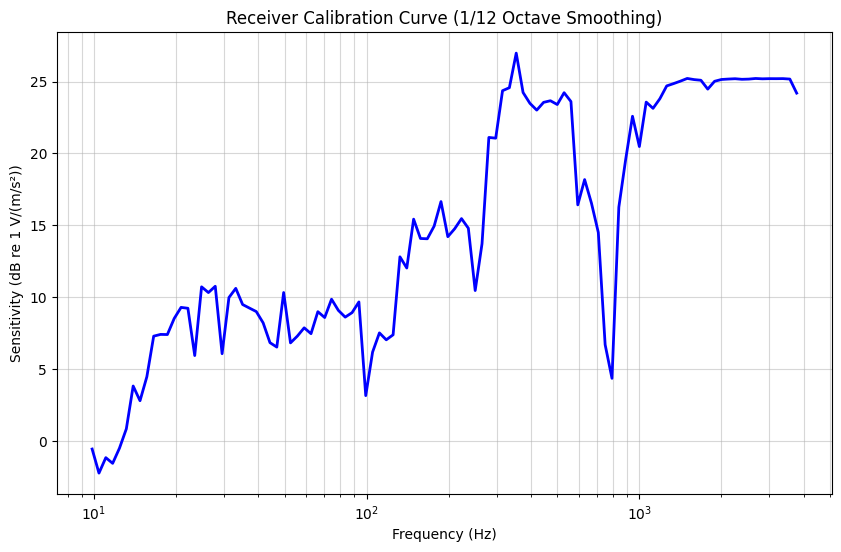

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_fractional_octave_bands(f_min, f_max, fraction=3):
    """Генерация граничных частот для дробно-октавных фильтров."""
    # Опорная частота по стандарту ISO 266
    f_ref = 1000.0
    
    # Расчет индексов полос
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    # Центральные и граничные частоты
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    
    return f_lower, f_center, f_upper

def calibrate_receiver(file_path, duration_min=1):
    # 1. Загрузка данных
    fs, data = wavfile.read(file_path)
    # Нормализация, если файл 16-bit (зависит от АЦП)
    if data.dtype == np.int16:
        data = data / 32768.0
        
    ch_ref = data[:, 0]  # Эталон (m/s2)
    ch_rec = data[:, 1]  # Приемник (V)
    
    samples_per_seg = int(fs * duration_min * 60)
    num_segments = len(data) // samples_per_seg
    
    # Параметры октавных полос (например, от 10 Гц до 20 кГц)
    f_low, f_mid, f_high = get_fractional_octave_bands(10, fs/2.2, fraction=12)
    
    psd_ref_avg = []
    psd_rec_avg = []

    # 2. Обработка сегментов
    for i in range(num_segments):
        start = i * samples_per_seg
        end = start + samples_per_seg
        
        # Считаем спектральную плотность мощности (PSD)
        # nperseg выбираем так, чтобы разрешение было ~1/60 Гц (fs * 60)
        f, p_ref = welch(ch_ref[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(ch_rec[start:end], fs, nperseg=fs*60, window='hann')
        
        # 3. Интегрирование в 1/12 октавных полосах
        band_energy_ref = []
        band_energy_rec = []
        
        for fl, fh in zip(f_low, f_high):
            mask = (f >= fl) & (f < fh)
            band_energy_ref.append(np.trapz(p_ref[mask], f[mask]))
            band_energy_rec.append(np.trapz(p_rec[mask], f[mask]))
            
        psd_ref_avg.append(band_energy_ref)
        psd_rec_avg.append(band_energy_rec)

    # 4. Усреднение по всем минутам
    mean_ref = np.sqrt(np.mean(psd_ref_avg, axis=0)) # RMS в полосе
    mean_rec = np.sqrt(np.mean(psd_rec_avg, axis=0)) # RMS в полосе
    
    # 5. Расчет чувствительности в дБ
    # Чувствительность S = V / (m/s2)
    sensitivity = 20 * np.log10(mean_rec / mean_ref)
    
    return f_mid, sensitivity

# Визуализация результатов
freqs, sens_db = calibrate_receiver('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

plt.figure(figsize=(10, 6))
plt.semilogx(freqs, sens_db, label='Sensitivity Curve', color='blue', linewidth=2)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Sensitivity (dB re 1 V/(m/s²))')
plt.title('Receiver Calibration Curve (1/12 Octave Smoothing)')
plt.show()

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2709/2101549000.py:22: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


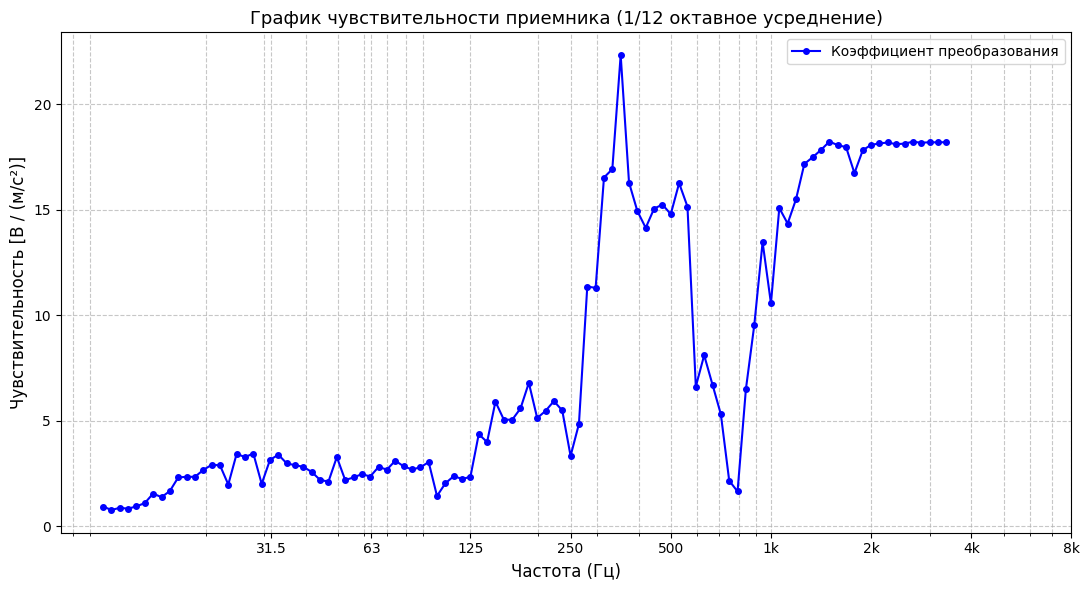

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_octave_bands(f_min, f_max, fraction=3):
    """Генерация частотных полос для 1/12 октавы."""
    f_ref = 1000.0  # Стандартная опорная частота
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    # Границы полос
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    
    return f_lower, f_center, f_upper

def calculate_sensitivity(file_path, duration_min=1):
    # 1. Чтение файла
    fs, data = wavfile.read(file_path)
    
    # Если файл в целочисленном формате, приводим к float
    # ВАЖНО: предполагаем, что шкала WAV уже соответствует физическим единицам
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]  # Канал 1: Эталон [м/с^2]
    rec_volts = data[:, 1]  # Канал 2: Приемник [В]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    # Частотный диапазон (можно настроить под ваши задачи)
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    # Массивы для накопления мощностей по сегментам
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    # 2. Посегментная обработка (по 1 минуте)
    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        # Считаем PSD. nperseg=fs*60 дает разрешение 1/60 Гц
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        # Интегрируем мощность в полосах 1/12 октавы
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                # Суммируем спектральную плотность мощности в полосе
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    # 3. Усреднение и переход к среднеквадратичным значениям (RMS)
    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    

    
    # 4. Расчет чувствительности [В / (м/с^2)]
    # Чтобы избежать деления на ноль в пустых полосах
    sensitivity = np.divide(rms_rec, rms_ref, out=np.zeros_like(rms_rec), where=rms_ref!=0)
    
    return f_mid, sensitivity

# --- Запуск и визуализация ---
# Замените 'data.wav' на ваше имя файла
try:
    freqs, sens_linear = calculate_sensitivity('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    plt.figure(figsize=(11, 6))
    plt.semilogx(freqs, sens_linear, 'b-o', markersize=4, label='Коэффициент преобразования')
    
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.xlabel('Частота (Гц)', fontsize=12)
    plt.ylabel('Чувствительность [В / (м/с²)]', fontsize=12)
    plt.title('График чувствительности приемника (1/12 октавное усреднение)', fontsize=13)
    plt.legend()
    
    # Добавим подписи на основных октавных частотах для удобства
    plt.xticks([31.5, 63, 125, 250, 500, 1000, 2000, 4000, 8000], 
               ['31.5', '63', '125', '250', '500', '1k', '2k', '4k', '8k'])
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден. Пожалуйста, проверьте путь к .wav файлу.")

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2709/3642298764.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


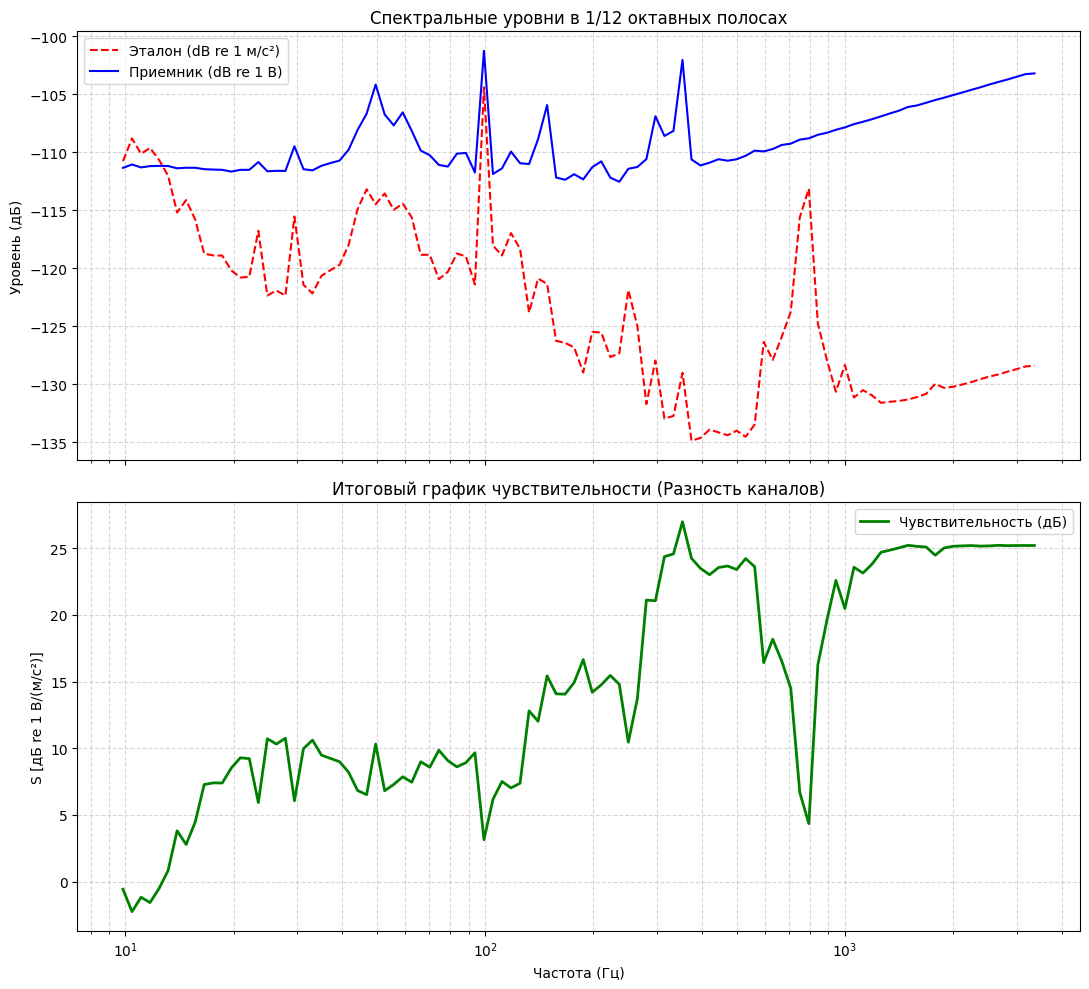

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_octave_bands(f_min, f_max, fraction=12):
    f_ref = 1000.0
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    return f_lower, f_center, f_upper

def calibrate_with_db(file_path, duration_min=1):
    fs, data = wavfile.read(file_path)
    
    # Приведение к float
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]  # [м/с^2]
    rec_volts = data[:, 1]  # [В]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    # Накопители для мощности
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        # Разрешение 1/60 Гц за счет nperseg=fs*60
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    # Среднеквадратичные значения (усреднение по времени)
    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    
    # Перевод в децибелы (уровни)
    # Используем 1e-12 как предохранитель от log(0)
    L_ref = 20 * np.log10(rms_ref + 1e-12) 
    L_rec = 20 * np.log10(rms_rec + 1e-12)
    
    # Чувствительность как разность уровней
    sensitivity_db = L_rec - L_ref
    
    return f_mid, L_ref, L_rec, sensitivity_db

# --- Визуализация ---
try:
    freqs, db_ref, db_rec, sens_db = calibrate_with_db('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

    # Верхний график: уровни сигналов
    ax1.semilogx(freqs, db_ref, 'r--', label='Эталон (dB re 1 м/с²)')
    ax1.semilogx(freqs, db_rec, 'b-', label='Приемник (dB re 1 В)')
    ax1.set_ylabel('Уровень (дБ)')
    ax1.set_title('Спектральные уровни в 1/12 октавных полосах')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()

    # Нижний график: чувствительность (разность)
    ax2.semilogx(freqs, sens_db, 'g', linewidth=2, label='Чувствительность (дБ)')
    ax2.set_ylabel('S [дБ re 1 В/(м/с²)]')
    ax2.set_xlabel('Частота (Гц)')
    ax2.set_title('Итоговый график чувствительности (Разность каналов)')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден.")

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2709/3812678656.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


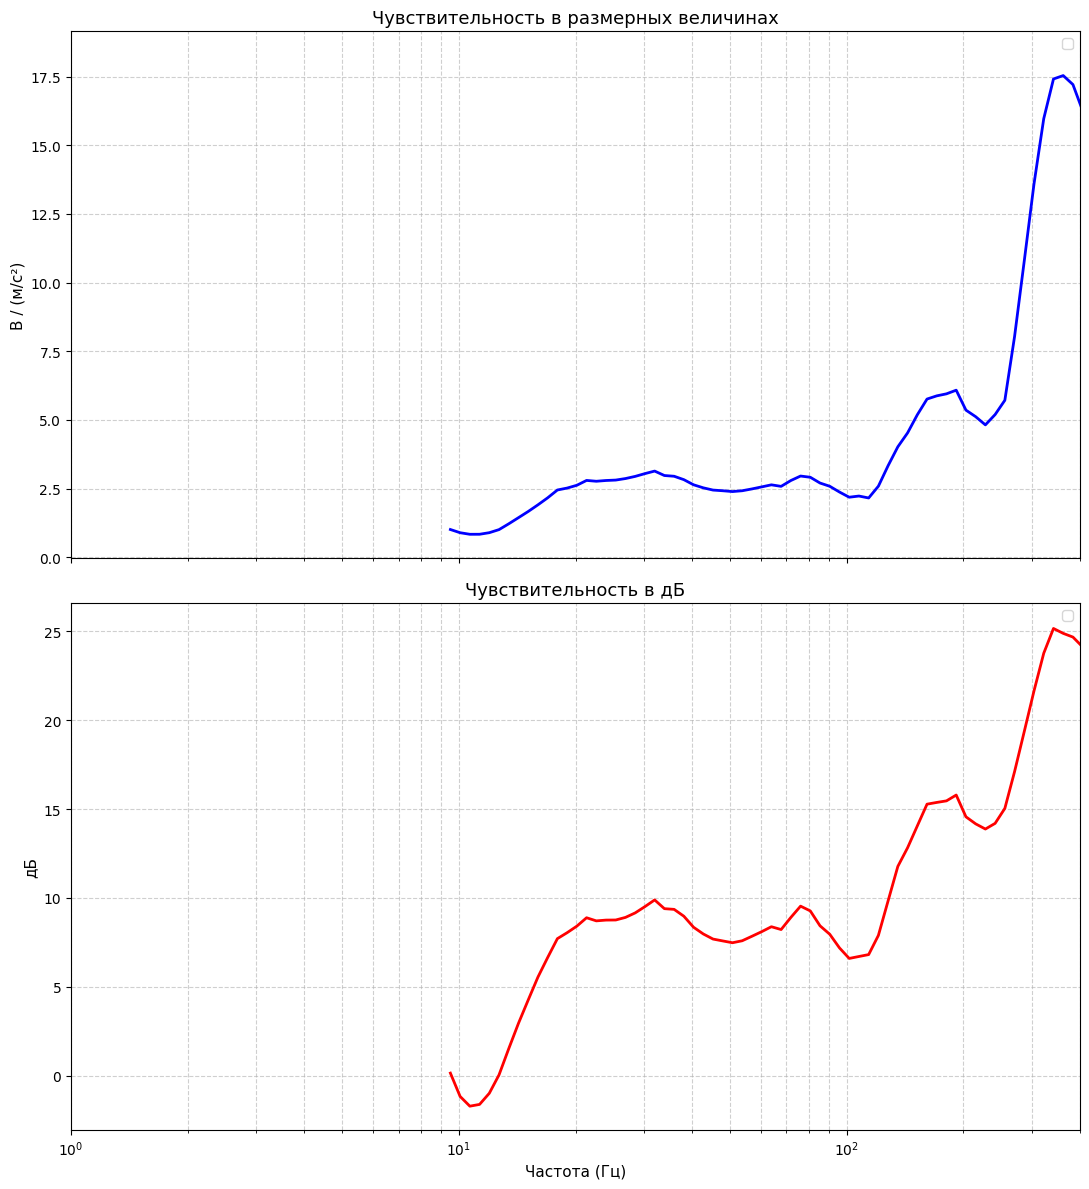

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch, savgol_filter

def get_octave_bands(f_min, f_max, fraction=3):
    f_ref = 1
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    return f_lower, f_center, f_upper

def run_calibration_smoothed(file_path, duration_min=1):
    fs, data = wavfile.read(file_path)
    
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]
    rec_volts = data[:, 1]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    
    sens_linear = np.divide(rms_rec, rms_ref, out=np.zeros_like(rms_rec), where=rms_ref!=0)
    sens_db = 20 * np.log10(rms_rec + 1e-12) - 20 * np.log10(rms_ref + 1e-12)
    
    # --- СГЛАЖИВАНИЕ ---
    # window_length должен быть нечетным числом и меньше длины массива
    window = 11 if len(f_mid) > 11 else (len(f_mid) // 2 * 2 - 1)
    poly_order = 3 # Порядок полинома
    
    sens_lin_smooth = savgol_filter(sens_linear, window, poly_order)
    sens_db_smooth = savgol_filter(sens_db, window, poly_order)
    
    return f_mid, sens_linear, sens_lin_smooth, sens_db, sens_db_smooth

# --- Визуализация ---
try:
    freqs, s_lin, s_lin_s, s_db, s_db_s = run_calibration_smoothed('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 12), sharex=True)

    # График 1: Линейная чувствительность
    #ax1.semilogx(freqs, s_lin, color='gray', alpha=0.3, label='Исходные данные')
    ax1.semilogx(freqs, s_lin_s, 'b', linewidth=2)
    ax1.set_ylabel('В / (м/с²)', fontsize=11)
    ax1.set_title('Чувствительность в размерных величинах', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.6)
    ax1.set_xlim([1, 400])  # Ограничение по X от 20 Гц до 1000 Гц
    ax1.legend()

    # График 2: Чувствительность в дБ
    #ax2.semilogx(freqs, s_db, color='gray', alpha=0.3, label='Исходные данные')
    ax2.semilogx(freqs, s_db_s, 'r', linewidth=2)
    ax2.set_ylabel('дБ', fontsize=11)
    ax2.set_xlabel('Частота (Гц)', fontsize=11)
    ax2.set_title('Чувствительность в дБ', fontsize=13)
    ax2.grid(True, which="both", ls="--", alpha=0.6)
    ax2.set_xlim([1, 400])
    ax2.legend()

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден.")

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_2709/3031239629.py:19: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


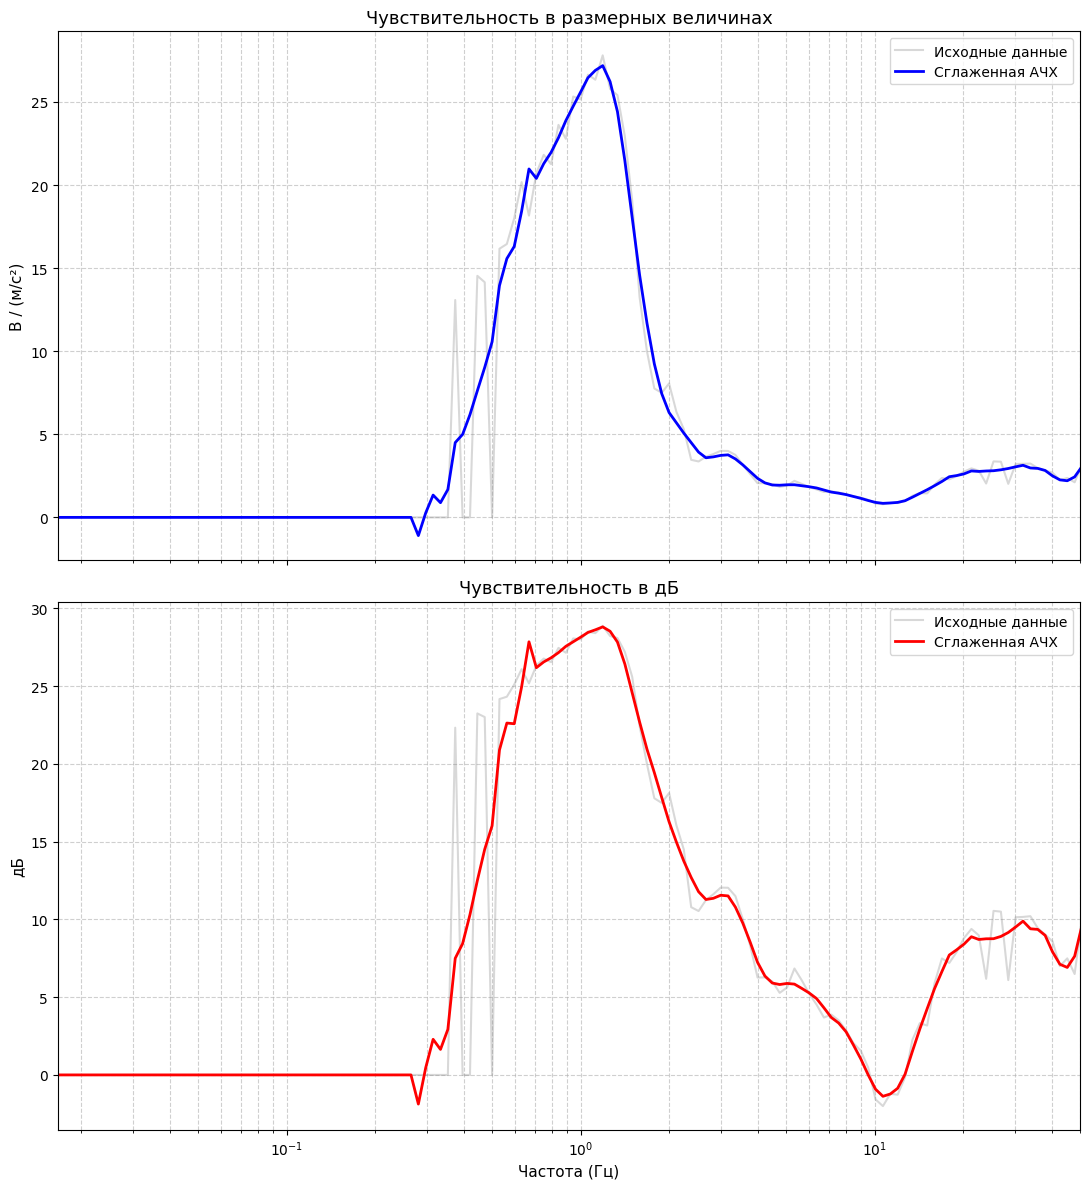

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch, savgol_filter

def get_octave_bands(f_min, f_max, fraction=12):
    # Опорная частота 1 Гц отлично подходит для инфразвука и низких частот
    f_ref = 1.0
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    return f_lower, f_center, f_upper

def run_calibration_smoothed(file_path, duration_min=1):
    fs, data = wavfile.read(file_path)
    
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]
    rec_volts = data[:, 1]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    # ИЗМЕНЕНИЕ 1: Задаем диапазон от 1/60 Гц до 50 Гц
    f_low, f_mid, f_high = get_octave_bands(1/60, 50, fraction=12)
    
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        # Шаг nperseg=fs*60 дает спектральные линии точно через 1/60 Гц
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    
    sens_linear = np.divide(rms_rec, rms_ref, out=np.zeros_like(rms_rec), where=rms_ref!=0)
    sens_db = 20 * np.log10(rms_rec + 1e-12) - 20 * np.log10(rms_ref + 1e-12)
    
    # --- СГЛАЖИВАНИЕ ---
    window = 11 if len(f_mid) > 11 else (len(f_mid) // 2 * 2 - 1)
    poly_order = 3 
    
    sens_lin_smooth = savgol_filter(sens_linear, window, poly_order)
    sens_db_smooth = savgol_filter(sens_db, window, poly_order)
    
    return f_mid, sens_linear, sens_lin_smooth, sens_db, sens_db_smooth

# --- Визуализация ---
try:
    # Путь к вашему файлу
    file_path = '/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav'
    freqs, s_lin, s_lin_s, s_db, s_db_s = run_calibration_smoothed(file_path)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 12), sharex=True)

    # График 1: Линейная чувствительность
    ax1.semilogx(freqs, s_lin, color='gray', alpha=0.3, label='Исходные данные')
    ax1.semilogx(freqs, s_lin_s, 'b', linewidth=2, label='Сглаженная АЧХ') # Раскомментировали и заменили на semilogx
    ax1.set_ylabel('В / (м/с²)', fontsize=11)
    ax1.set_title('Чувствительность в размерных величинах', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.6)
    ax1.set_xlim([1/60, 50])  # ИЗМЕНЕНИЕ 2: Ноль заменен на 1/60
    ax1.legend()

    # График 2: Чувствительность в дБ
    ax2.semilogx(freqs, s_db, color='gray', alpha=0.3, label='Исходные данные')
    ax2.semilogx(freqs, s_db_s, 'r', linewidth=2, label='Сглаженная АЧХ') # Раскомментировали и заменили на semilogx
    ax2.set_ylabel('дБ', fontsize=11)
    ax2.set_xlabel('Частота (Гц)', fontsize=11)
    ax2.set_title('Чувствительность в дБ', fontsize=13)
    ax2.grid(True, which="both", ls="--", alpha=0.6)
    ax2.set_xlim([1/60, 50])  # ИЗМЕНЕНИЕ 2: Ноль заменен на 1/60
    ax2.legend()

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден. Проверьте правильность пути.")